# Outline of the main script

In [118]:

#imports:

from chime.calibration import load_Learmonth_data
from scipy import interpolate
import matplotlib.pyplot as plt


import numpy as np
import pandas as pd

import glob
from tqdm import trange
import os
from datetime import datetime


#placing the files in here:

learmonth = '/home/scratch/dbautist/CHIME_archive/learmonthData/'
learmonth_files = glob.glob(f'{learmonth}/L24*SRD')

#def month_organization(month_dict):
 #   month_dict = {}
  #  for month in month_dict:
   ##    month_dict[month] = glob.glob(f'{learmonth}/L25{month}*SRD')
    #return month
    
months = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
month_dict = {}

for month in months:
    string = ""
    month_dict[month] = glob.glob(f'{learmonth}/L24{month}*SRD')

day_path = month_dict['12'][0]
df = load_Learmonth_data(day_path)
    
#Filtering process:

def filtering(df):
    '''
    This function takes in two arguments, median and result.  Median takes in the Learmonth data
    and plucks out the days that have good data.  This means days that have some form of flux and then
    calculates the median of that certian day, making sure to leave out the bad days of data.'''
    
    median = (not np.isnan(np.nanmedian(df['410']))) and np.nanmedian(df['410']) !=1 and np.nanmedian(df['410'])
    result = median
    return result

good_dat = []
bad_dat = []
   
for month in months:
    for i in trange(len(month_dict[month])):
        path = month_dict[month][i]
        df = load_Learmonth_data(path)
           
        if filtering(df):
            good_dat.append(path)
        else:
            bad_dat.append(path)
            


 58%|█████▊    | 18/31 [01:31<01:06,  5.08s/it]/tmp/ipykernel_520366/3827076143.py:46: RuntimeWarning: All-NaN slice encountered
  median = (not np.isnan(np.nanmedian(df['410']))) and np.nanmedian(df['410']) !=1 and np.nanmedian(df['410'])
100%|██████████| 31/31 [02:28<00:00,  4.80s/it]


In [119]:

            
def date_values(good_dat, bad_dat):
    '''
    There are 2 arguments present in this function:
        good_dat: list of data that was made above, that holds all the good data that was filtered out of 
        the original list
        bad_dat: list of the data that filters out all the days that have only NaNs in their system.
    This function's purpose is to change these datetime values in the lists above into usable numbers 
    for interpoliation reasons'''
    
    good_date = []
    bad_date = []
    
    for date in good_dat:
        base = os.path.basename(date)[3:7]
        num_date = int(base)
        good_date.append(num_date)
    
    for nodate in bad_dat:
        nobase = os.path.basename(nodate)[3:7]
        no_num_date = int(nobase)
        bad_date.append(no_num_date)
    
    return good_date, bad_date
        
def time_of_date(good_dat, bad_dat):
    '''
    This function also has two arguments: good_dat, and bad_dat once again.  THe purpoce of this funcion
    is to convert the previous lists into a strtime form of L%y%m%d.SRD so it reconizes that form and 
    actually gives us numbers to work with.'''
    
    good_datetime = []
    bad_datetimes_NaN = []
    
    for good in good_dat:
        file = os.path.basename(good)
        new_var = datetime.strptime(file, "L%y%m%d.SRD")
        good_datetime.append(new_var)
        
    for bad in bad_dat:
        fileb = os.path.basename(bad)
        bad_var = datetime.strptime(fileb, "L%y%m%d.SRD")
        bad_datetimes_NaN.append(bad_var)
        
    return good_datetime, bad_datetimes_NaN


In [120]:

nonexistant_days =  [datetime.strptime("L240223.SRD", "L%y%m%d.SRD"), 
                        datetime.strptime("L240224.SRD", "L%y%m%d.SRD"),
                        datetime.strptime("L240226.SRD", "L%y%m%d.SRD"),
                        datetime.strptime("L240227.SRD", "L%y%m%d.SRD"),
                        datetime.strptime("L240616.SRD", "L%y%m%d.SRD"),
                        ]
nonexistant_days.sort()

def flux_calibration(good_dat):
    '''
    This function is taking the data in good_dat and extracting the median of each individual day that exist for a 
    solar flux value through a loop.  Then afterwards, converting them from unitless counts into units of Janskys, 
    placing them into another list known as flux_Jy.'''
    
    raw_flux = []
    
    for i in trange(len(good_dat)):
        p = good_dat[i]
        df = load_Learmonth_data(p)
        raw_flux.append(np.nanmedian(df['410']))
    
    flux_Jy = [x * 10000 for x in raw_flux]
    return flux_Jy


In [121]:

good_date, bad_date = date_values(good_dat, bad_dat)
good_datetime, bad_datetimes_NaN = time_of_date(good_dat, bad_dat)
flux_Jy = flux_calibration(good_dat)


bad_datetimes_total = sorted(bad_datetimes_NaN + nonexistant_days)
dates = sorted(good_date + bad_date)


100%|██████████| 292/292 [22:57<00:00,  4.72s/it]


In [122]:
len(bad_dat)

69

In [123]:

#Data sorting: 

known_jan_points = list(range(101, 132))
known_feb_points = list(range(201, 230))
known_mar_points = list(range(301, 332))
known_apr_points = list(range(401, 431))
known_may_points = list(range(501, 532))
known_jun_points = list(range(601, 631))
known_jul_points = list(range(701, 732))
known_aug_points = list(range(801, 832))
known_sept_points = list(range(901, 931))
known_oct_points = list(range(1001, 1131))
known_nov_points = list(range(1101, 1131))
known_dec_points = list(range(1201, 1232))

real1 = dates[0:31]      #Jan
real2 = dates[31:56]
real3 = dates[48:79]
real4 = dates[80:110]
real5 = dates[111:142]
real6 = dates[143:178]
real7 = dates[179:208]   #July
real8 = dates[207:237]   #August
real9 = dates[237:266]   #Sept
real10 = dates[265:296]
real11 = dates[295:325]
real12 = dates[325:365]

dont_existFeb = [item for item in known_feb_points if item not in real2]
dont_existJu = [item for item in known_jun_points if item not in real6]


dont_exist = sorted(dont_existFeb + dont_existJu)
bad_dates_total = sorted(bad_date + dont_exist)


In [124]:
len(bad_dates_total)

74

In [125]:

#interpolating:

f = interpolate.interp1d((good_date), (flux_Jy))

good_thing = f(good_date)
est_flux = f(bad_dates_total)

for num in bad_dates_total:
    date_str = f"{int(num):04d}"
    full_date_str = f"2024{date_str}"
    
    dt_obj = datetime.strptime(full_date_str, "%Y%m%d")
    

In [126]:
print(bad_datetimes_total)

[datetime.datetime(2024, 1, 19, 0, 0), datetime.datetime(2024, 1, 20, 0, 0), datetime.datetime(2024, 1, 21, 0, 0), datetime.datetime(2024, 1, 22, 0, 0), datetime.datetime(2024, 1, 23, 0, 0), datetime.datetime(2024, 1, 24, 0, 0), datetime.datetime(2024, 1, 25, 0, 0), datetime.datetime(2024, 1, 26, 0, 0), datetime.datetime(2024, 1, 27, 0, 0), datetime.datetime(2024, 1, 28, 0, 0), datetime.datetime(2024, 1, 29, 0, 0), datetime.datetime(2024, 1, 30, 0, 0), datetime.datetime(2024, 1, 31, 0, 0), datetime.datetime(2024, 2, 1, 0, 0), datetime.datetime(2024, 2, 2, 0, 0), datetime.datetime(2024, 2, 3, 0, 0), datetime.datetime(2024, 2, 4, 0, 0), datetime.datetime(2024, 2, 5, 0, 0), datetime.datetime(2024, 2, 6, 0, 0), datetime.datetime(2024, 2, 7, 0, 0), datetime.datetime(2024, 2, 8, 0, 0), datetime.datetime(2024, 2, 9, 0, 0), datetime.datetime(2024, 2, 10, 0, 0), datetime.datetime(2024, 2, 11, 0, 0), datetime.datetime(2024, 2, 12, 0, 0), datetime.datetime(2024, 2, 13, 0, 0), datetime.datetime(20

In [127]:
len(bad_dates_total)

74

In [128]:
len(bad_datetimes_total)

74

In [129]:

#Pandas dataframes:

good_flux_data = {
    "Date": good_datetime,
    "Flux": flux_Jy,
    "Source": "Real"
}

bad_flux_data = {
    "Date": bad_datetimes_total,
    "Flux": est_flux,
    "Source": "Interpoliated"
}

good = pd.DataFrame(good_flux_data)
bad = pd.DataFrame(bad_flux_data)

total = [good, bad]
full_list = pd.concat(total)
full_list_sort = full_list.sort_values(by=["Date"])

full_list_sort["Date"] == str

full_list_sort.to_csv("testing_flux_data_2024.csv", index=False)

In [130]:
len(bad_datetimes_total)

74

In [131]:
len(bad_datetimes_total)

74

In [132]:
len(est_flux)

74

In [133]:
print(bad_datetimes_total)

[datetime.datetime(2024, 1, 19, 0, 0), datetime.datetime(2024, 1, 20, 0, 0), datetime.datetime(2024, 1, 21, 0, 0), datetime.datetime(2024, 1, 22, 0, 0), datetime.datetime(2024, 1, 23, 0, 0), datetime.datetime(2024, 1, 24, 0, 0), datetime.datetime(2024, 1, 25, 0, 0), datetime.datetime(2024, 1, 26, 0, 0), datetime.datetime(2024, 1, 27, 0, 0), datetime.datetime(2024, 1, 28, 0, 0), datetime.datetime(2024, 1, 29, 0, 0), datetime.datetime(2024, 1, 30, 0, 0), datetime.datetime(2024, 1, 31, 0, 0), datetime.datetime(2024, 2, 1, 0, 0), datetime.datetime(2024, 2, 2, 0, 0), datetime.datetime(2024, 2, 3, 0, 0), datetime.datetime(2024, 2, 4, 0, 0), datetime.datetime(2024, 2, 5, 0, 0), datetime.datetime(2024, 2, 6, 0, 0), datetime.datetime(2024, 2, 7, 0, 0), datetime.datetime(2024, 2, 8, 0, 0), datetime.datetime(2024, 2, 9, 0, 0), datetime.datetime(2024, 2, 10, 0, 0), datetime.datetime(2024, 2, 11, 0, 0), datetime.datetime(2024, 2, 12, 0, 0), datetime.datetime(2024, 2, 13, 0, 0), datetime.datetime(20

In [134]:
print(bad_dates_total)

[119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 303, 318, 325, 326, 327, 328, 331, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 426, 608, 616, 629, 711, 730, 826, 1201]


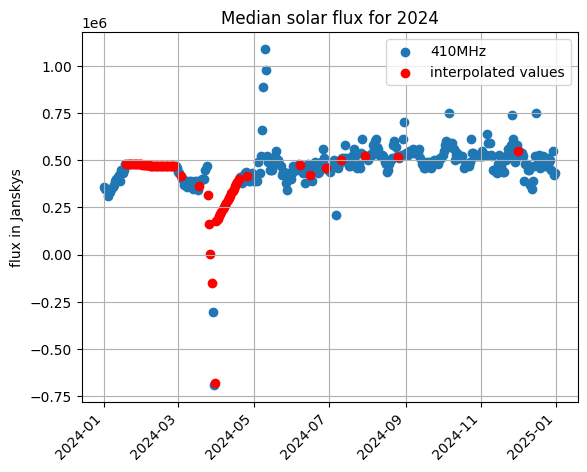

In [ ]:
plt.figure()
plt.scatter(good_datetime, flux_Jy, label='410MHz')
plt.scatter(bad_datetimes_total, est_flux, color='red', label='interpolated values')
#m = np.linspace(bad_datetimes[1], bad_datetimes[31])
#plt.plot(m, f(m), color='lightgreen', label='fit')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.title(f"Median solar flux for 2024")
plt.ylabel("flux in Janskys")

plt.grid()
#plt.hlines(np.median(flux_410), min(good_data), max(good_data))
plt.legend()